In [ ]:
import pandas as pd

# 1. Đường dẫn file cần xử lý
file_path = 'products_child_clothes.csv'

# 2. Đọc file
df = pd.read_csv(file_path)
print(f"Số dòng ban đầu: {len(df)}")

# 3. Loại bỏ các dòng thiếu dữ liệu
# how='any': Xóa dòng nếu có BẤT KỲ cột nào bị trống
df.dropna(how='any', inplace=True)

# 4. Ghi đè lại file gốc
df.to_csv(file_path, index=False)

print(f"Số dòng sau khi làm sạch: {len(df)}")
print(f"Đã ghi đè thành công lên file: {file_path}")

Số dòng ban đầu: 440
Số dòng sau khi làm sạch: 364
Đã ghi đè thành công lên file: ./data/products_child_clothes.csv


In [ ]:
import pandas as pd
import re

# 1. Đọc file
file_path = 'products_child_clothes.csv'
df = pd.read_csv(file_path)

# 2. Hàm xử lý dữ liệu (ĐÃ SỬA LỖI GIÁ)
def clean_currency(x):
    if pd.isna(x): return 0
    s = str(x)
    
    # Bước sửa lỗi: Nếu chuỗi kết thúc bằng .0 (do pandas format), hãy cắt bỏ nó đi
    if s.endswith('.0'):
        s = s[:-2]
        
    # Sau đó mới xóa các ký tự không phải số (dấu chấm phân cách ngàn, chữ đ...)
    clean_str = re.sub(r'[^\d]', '', s)
    return float(clean_str) if clean_str else 0

def clean_percent(x):
    if pd.isna(x): return 0
    clean_str = re.sub(r'[^\d.]', '', str(x))
    return float(clean_str) if clean_str else 0

def clean_sold(x):
    if pd.isna(x): return 0
    x = str(x).lower().replace(' đã bán', '').strip()
    if 'k' in x:
        return float(re.sub(r'[^\d.]', '', x)) * 1000
    else:
        return float(re.sub(r'[^\d.]', '', x)) if re.sub(r'[^\d.]', '', x) else 0

def clean_comment(x):
    if pd.isna(x): return 0
    return float(re.sub(r'[^\d]', '', str(x)))

# 3. Áp dụng chuẩn hóa
df['price'] = df['price'].apply(clean_currency)
df['original_price'] = df['original_price'].apply(clean_currency)
df['discount_percent'] = df['discount_percent'].apply(clean_percent)
df['sold'] = df['sold'].apply(clean_sold)
df['comment_count'] = df['comment_count'].apply(clean_comment)

# 4. Xử lý cột category_group
keep_categories = ["Chăm sóc da mặt", "Khác", "Đồ điện tử khác", "Thời trang khác", "Điện", "Phụ kiện điện thoại & máy tính bảng"]

def assign_category_group(cat_name):
    # Cần convert sang str để tránh lỗi nếu cat_name bị nan
    cat_str = str(cat_name) 
    if cat_str in keep_categories:
        return cat_str
    else:
        return "Quần áo trẻ em"

df['category_group'] = df['category'].apply(assign_category_group)

# 5. Sắp xếp và chọn cột
target_columns = [
    'category', 'store_name', 'original_price', 'discount_percent', 
    'price', 'comment_count', 'rating', 'name', 'sold', 'category_group'
]

for col in target_columns:
    if col not in df.columns:
        df[col] = 0 

df_clean = df[target_columns]

# 6. Kiểm tra
print("\nDữ liệu sau khi chuẩn hóa:")
print(df_clean[['original_price', 'price']].head()) # In thử giá để kiểm tra
print(df_clean.info())

# 7. Lưu file
output_file = './data/products_child_clothes_clean.csv'
df_clean.to_csv(output_file, index=False)
print(f"\nĐã lưu file chuẩn hóa: {output_file}")


Dữ liệu sau khi chuẩn hóa:
   original_price     price
0        185000.0  109150.0
1        159000.0  103350.0
2        178000.0   89000.0
3         59000.0   56050.0
4         98000.0   44100.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   category          364 non-null    object 
 1   store_name        364 non-null    object 
 2   original_price    364 non-null    float64
 3   discount_percent  364 non-null    float64
 4   price             364 non-null    float64
 5   comment_count     364 non-null    float64
 6   rating            364 non-null    float64
 7   name              364 non-null    object 
 8   sold              364 non-null    float64
 9   category_group    364 non-null    object 
dtypes: float64(6), object(4)
memory usage: 28.6+ KB
None

Đã lưu file chuẩn hóa: ./data/products_child_clothes_clean.csv


In [ ]:
import pandas as pd

# 1. Đọc file
# Thay bằng tên file bạn đang xử lý
file_path = 'product_detail_fixed.csv' 
df = pd.read_csv(file_path)

# 2. QUAN TRỌNG: Ép kiểu cột rating và comment_count về dạng số
# errors='coerce': Biến các giá trị lỗi (text, ký tự lạ) thành NaN (Not a Number) để không bị crash
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['comment_count'] = pd.to_numeric(df['comment_count'], errors='coerce')

# 3. Sau khi ép kiểu xong, lệnh so sánh mới hoạt động được
mask = df['rating'] > 5

if mask.any():
    print(f"Phát hiện {mask.sum()} dòng bị ngược rating, đang sửa...")
    # Hoán đổi giá trị
    # Lấy .values để gán giá trị thuần túy, tránh lỗi index
    df.loc[mask, ['rating', 'comment_count']] = df.loc[mask, ['comment_count', 'rating']].values
else:
    print("Dữ liệu rating bình thường, không có dòng nào > 5.")

# 4. Lưu lại
df.to_csv(file_path, index=False)
print("Đã hoàn tất xử lý!")

In [ ]:
import pandas as pd

# 1. Đọc file dữ liệu
# Đảm bảo bạn trỏ đúng file đang cần kiểm tra
file_path = 'product_detail_fixed.csv' 
df = pd.read_csv(file_path)

# 2. Định nghĩa các cột dùng để xét trùng
subset_cols = ['name', 'store_name', 'price', 'original_price']

# 3. Tìm các dòng trùng
# keep=False: Hiển thị tất cả các bản ghi bị trùng để xem
duplicates = df[df.duplicated(subset=subset_cols, keep=False)]

# Sắp xếp để dễ nhìn
duplicates_sorted = duplicates.sort_values(by='name')

if len(duplicates_sorted) > 0:
    print(f"Tìm thấy {len(duplicates_sorted)} dòng bị trùng dựa trên các cột: {subset_cols}")
    print("Ví dụ 5 dòng đầu tiên:")
    print(duplicates_sorted[subset_cols].head())
    
    # Lưu ra file để kiểm tra nếu cần
    duplicates_sorted.to_csv('./data/kiem_tra_trung_lap.csv', index=False)
else:
    print("Không tìm thấy dòng nào trùng lặp với các tiêu chí trên.")

Tìm thấy 172 dòng bị trùng dựa trên các cột: ['name', 'store_name', 'price', 'original_price']
Ví dụ 5 dòng đầu tiên:
                                                   name          store_name  \
6995  ( 7-27kg ) Bộ MINKY MOM Bé Trai Bé Gái Đồ Bộ D...  Minky Mom Miền Nam   
6864  ( 7-27kg ) Bộ MINKY MOM Bé Trai Bé Gái Đồ Bộ D...  Minky Mom Miền Nam   
6996  (10-62kg) Đồ bộ bé trai vải xuất  Pingbong hoạ...           Uyên Kids   
6924  (10-62kg) Đồ bộ bé trai vải xuất  Pingbong hoạ...           Uyên Kids   
6883  (12-64kg) Bộ Quần Áo Sát Nách Bé Trai Mặc Nhà,...      ZAkids Fashion   

         price original_price  
6995   65934.0        99900.0  
6864   65934.0        99900.0  
6996   78210.0        99000.0  
6924   78210.0        99000.0  
6883  123750.0       275000.0  


In [ ]:
import pandas as pd

file_path = 'product_detail_fixed.csv'
df = pd.read_csv(file_path)

print(f"Số dòng ban đầu: {len(df)}")

# Các cột xét trùng
subset_cols = ['name', 'store_name', 'price', 'original_price']

# Xóa trùng lặp, giữ dòng đầu tiên (keep='first')
df.drop_duplicates(subset=subset_cols, keep='first', inplace=True)

print(f"Số dòng sau khi xóa trùng: {len(df)}")

# Lưu đè file
df.to_csv(file_path, index=False)
print("Đã xóa trùng lặp và lưu file thành công!")

Số dòng ban đầu: 7064
Số dòng sau khi xóa trùng: 7064
Đã xóa trùng lặp và lưu file thành công!


In [ ]:
import pandas as pd

# 1. Đọc file dữ liệu hiện tại
file_path = 'product_detail_fixed.csv'
df = pd.read_csv(file_path)

print("Số lượng danh mục trước khi gộp:")
print(df['category_group'].value_counts())

# 2. Định nghĩa danh sách các danh mục cần gộp
# Bên trái (Key) là tên muốn thay đổi, Bên phải (Value) là tên đích đến
mapping_dict = {
    'Snacks & Confectionery': 'Đồ ăn nhẹ & bánh kẹo',
    'Food Staples & Cooking Essentials': 'Nguyên liệu nấu ăn & làm bánh',
    'Mobile & Tablet Accessories': 'Phụ kiện điện thoại & máy tính bảng',
    
    # Bạn có thể bỏ comment các dòng dưới nếu muốn dịch luôn các danh mục tiếng Anh còn lại
    'Pet Food': 'Chăm sóc thú cưng',
    'Kitchen Appliances': 'Thiết bị điện gia dụng',
    'Tableware': 'Dụng cụ bàn ăn',
    'Milk Formula & Baby Food': 'Sữa công thức & Ăn dặm',
    'Smartphones': 'Điện thoại & Phụ kiện',
}

# 3. Thực hiện thay thế
# Hàm replace sẽ chỉ thay thế những giá trị có trong từ điển, các giá trị khác giữ nguyên
df['category_group'] = df['category_group'].replace(mapping_dict)

# 4. Kiểm tra lại kết quả
print("\nSố lượng danh mục sau khi gộp:")
print(df['category_group'].value_counts())

# 5. Lưu đè lên file cũ (hoặc lưu ra file mới tùy bạn)
df.to_csv(file_path, index=False)
print(f"\nĐã hoàn tất đồng nhất danh mục và lưu vào file: {file_path}")

Số lượng danh mục trước khi gộp:
category_group
Đồ ăn nhẹ & bánh kẹo                   762
Nguyên liệu nấu ăn & làm bánh          695
Set bộ đi chơi                         568
Phụ kiện điện thoại & máy tính bảng    494
Đồ ngủ nữ                              399
Chăm sóc da mặt                        380
Quần áo trẻ em                         338
Điện                                   328
Thời trang khác                        326
Đồ điện tử khác                        326
Trang điểm                             285
Vali và Túi du lịch đa năng            280
Sữa công thức & Ăn dặm                 243
Chăm sóc thú cưng                      226
Áo                                     215
Khác                                   205
Dụng cụ chăm sóc Sắc đẹp               198
Điện thoại & Phụ kiện                  185
Phụ kiện Máy tính                      169
Đồ ăn khác                             109
Dụng cụ bàn ăn                          88
Thiết bị điện gia dụng                  82
Feedin

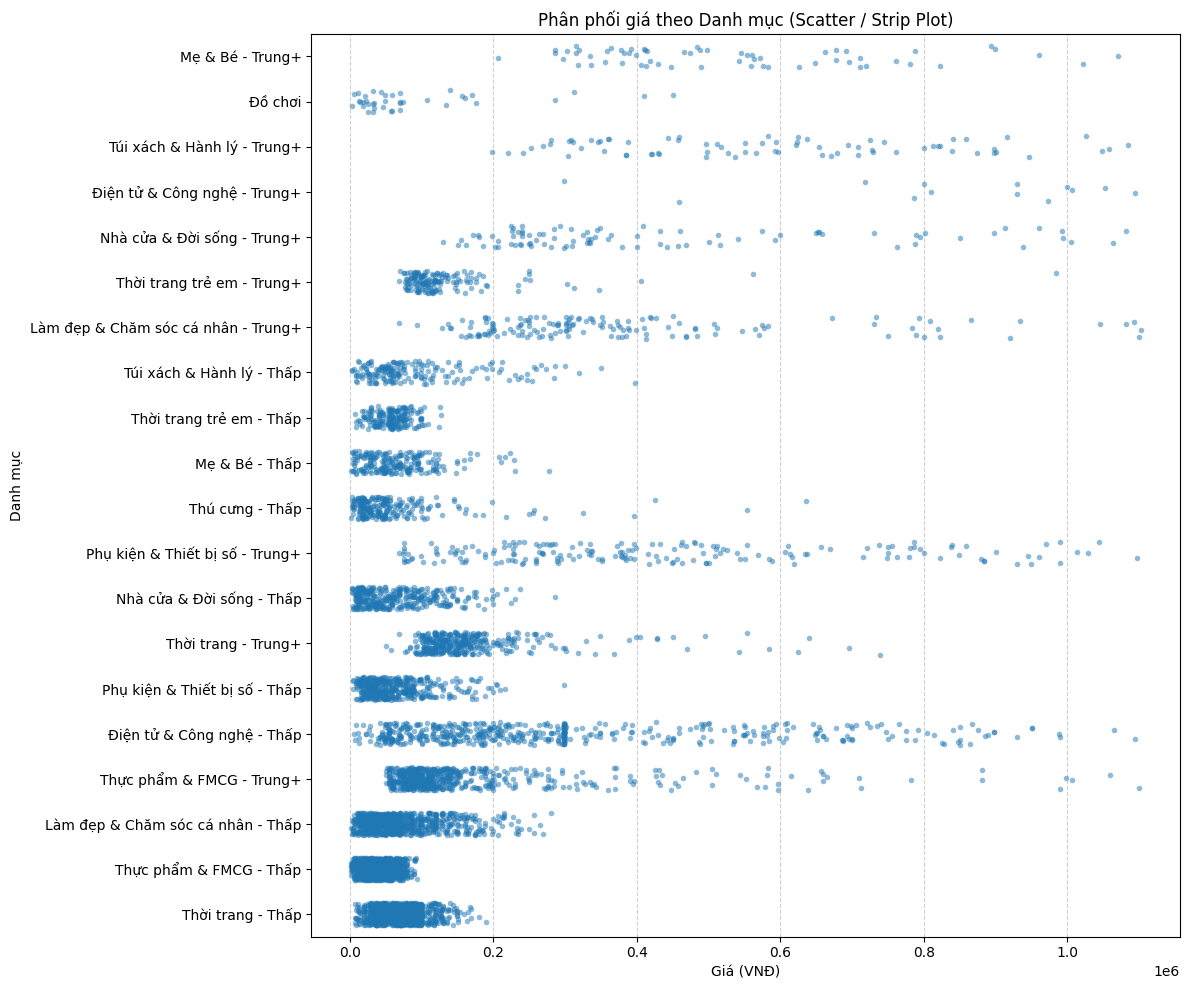

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load data
df = pd.read_csv('category_group_price_tier_review.csv')

# Loại top 5% giá cao để dễ nhìn
q95 = df['price'].quantile(0.95)
df_plot = df[df['price'] < q95]

# Tính số lượng để sắp xếp danh mục
stats = df.groupby('category_group')['price'].agg(['count']).reset_index()
stats = stats.sort_values(by='count', ascending=True)

# Vẽ scatter phân phối giá theo danh mục
plt.figure(figsize=(12, 10))
sns.stripplot(
    data=df_plot,
    y='category_group',
    x='price',
    order=stats['category_group'],
    jitter=0.25,
    alpha=0.5,
    size=4
)

plt.title('Phân phối giá theo Danh mục (Scatter / Strip Plot)')
plt.xlabel('Giá (VNĐ)')
plt.ylabel('Danh mục')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# ======================================================
# 1. LOAD DATA
# ======================================================
df = pd.read_csv("product_detail_fixed.csv")
OUTPUT_PATH = "category_group_price_tier_review.csv"

print("📥 Loaded data:", df.shape)

# ======================================================
# 2. CATEGORY → CATEGORY_GROUP MAPPING
# ======================================================
CATEGORY_GROUP_MAPPING = {

    # ===== THỜI TRANG =====
    "Set bộ đi chơi": "Thời trang",
    "Đồ ngủ nữ": "Thời trang",
    "Áo": "Thời trang",
    "Áo nữ": "Thời trang",
    "Quần": "Thời trang",
    "Quần, váy": "Thời trang",
    "Đầm": "Thời trang",
    "Bộ": "Thời trang",
    "Bộ đồ lót nữ": "Thời trang",
    "Đồ lót định hình": "Thời trang",
    "Tất & Quần tất": "Thời trang",
    "Trang Phục Thể Thao Nam": "Thời trang",
    "Trang Phục Thể Thao Nữ": "Thời trang",
    "Áo liền quần & áo liền quần": "Thời trang",
    "Trang phục văn hóa": "Thời trang",
    "Thời trang bầu": "Thời trang",
    "Đồ cặp đôi và gia đình": "Thời trang",
    "Quần áo thu/đông": "Thời trang",
    "Umbrellas & Raincoats": "Thời trang",
    "Đồng hồ": "Thời trang",
    "Accessories": "Thời trang",
    "Boots": "Thời trang",
    "Bottoms": "Thời trang",
    "Shapewear": "Thời trang",
    "Nhập vai Phục trang & Dạ tiệc": "Thời trang",
    "Pretend Play, Costumes & Party": "Thời trang",
    "Đồ châu báu": "Thời trang",
    "Phụ kiện": "Thời trang",

    # ===== THỜI TRANG TRẺ EM =====
    "Quần áo trẻ em": "Thời trang trẻ em",
    "Quần áo trẻ sơ sinh": "Thời trang trẻ em",
    "Baby Clothing": "Thời trang trẻ em",
    "Trang phục bé trai": "Thời trang trẻ em",
    "Phụ kiện trẻ em": "Thời trang trẻ em",

    # ===== LÀM ĐẸP & CHĂM SÓC CÁ NHÂN =====
    "Chăm sóc da mặt": "Làm đẹp & Chăm sóc cá nhân",
    "Trang điểm": "Làm đẹp & Chăm sóc cá nhân",
    "Makeup": "Làm đẹp & Chăm sóc cá nhân",
    "Dụng cụ chăm sóc Sắc đẹp": "Làm đẹp & Chăm sóc cá nhân",
    "Nước hoa": "Làm đẹp & Chăm sóc cá nhân",
    "Chăm sóc cá nhân": "Làm đẹp & Chăm sóc cá nhân",
    "Personal Care": "Làm đẹp & Chăm sóc cá nhân",
    "Chăm sóc cho Nam giới": "Làm đẹp & Chăm sóc cá nhân",
    "Personal Care Appliances": "Làm đẹp & Chăm sóc cá nhân",
    "Sexual Wellness": "Làm đẹp & Chăm sóc cá nhân",
    "Bath": "Làm đẹp & Chăm sóc cá nhân",
    "Đồ gia dụng chăm sóc cá nhân": "Làm đẹp & Chăm sóc cá nhân",
    "Thiết bị y tế": "Làm đẹp & Chăm sóc cá nhân",
    "Medical Supplies": "Làm đẹp & Chăm sóc cá nhân",


    # ===== ĐIỆN TỬ & CÔNG NGHỆ =====
    "Smartphones": "Điện tử & Công nghệ",
    "Điện": "Điện tử & Công nghệ",
    "Đồ điện tử khác": "Điện tử & Công nghệ",
    "Thiết bị đeo thông minh": "Điện tử & Công nghệ",
    "Nhà thông minh": "Điện tử & Công nghệ",
    "Camera giám sát & hệ thống": "Điện tử & Công nghệ",
    "Thiết bị âm thanh": "Điện tử & Công nghệ",
    "Thiết bị theo dõi GPS & Phụ kiện": "Điện tử & Công nghệ",
    "Điện thoại bàn": "Điện tử & Công nghệ",
    "Điện thoại cơ bản": "Điện tử & Công nghệ",
    "Máy tính bảng": "Điện tử & Công nghệ",
    "Scanners (Non-Printer)": "Điện tử & Công nghệ",
    "Network Components": "Điện tử & Công nghệ",
    "Phụ kiện trò chơi điện tử": "Điện tử & Công nghệ",
    "Thiết bị studio": "Điện tử & Công nghệ",

    # ===== PHỤ KIỆN & THIẾT BỊ SỐ =====
    "Phụ kiện điện thoại & máy tính bảng": "Phụ kiện & Thiết bị số",
    "Mobile & Tablet Accessories": "Phụ kiện & Thiết bị số",
    "Phụ kiện Máy tính": "Phụ kiện & Thiết bị số",
    "Camera Accessories": "Phụ kiện & Thiết bị số",
    "Thiết bị tiện ích USB": "Phụ kiện & Thiết bị số",
    "Phụ kiện Tivi & thiết bị video": "Phụ kiện & Thiết bị số",

    # ===== MẸ & BÉ =====
    "Milk Formula & Baby Food": "Mẹ & Bé",
    "Sữa công thức & Bột ăn dặm": "Mẹ & Bé",
    "Feeding Essentials": "Mẹ & Bé",
    "Baby & Kids' Accessories": "Mẹ & Bé",
    "Baby & Toddler Toys": "Mẹ & Bé",
    "Diapering & Potty": "Mẹ & Bé",
    "Baby Personal Care": "Mẹ & Bé",
    "Nursery": "Mẹ & Bé",
    "Đồ chơi cho trẻ sơ sinh & trẻ nhỏ": "Mẹ & Bé",

    # ===== THỰC PHẨM & FMCG =====
    "Nguyên liệu nấu ăn & làm bánh": "Thực phẩm & FMCG",
    "Food Staples & Cooking Essentials": "Thực phẩm & FMCG",
    "Snacks & Confectionery": "Thực phẩm & FMCG",
    "Đồ ăn nhẹ & bánh kẹo": "Thực phẩm & FMCG",
    "Bakery & Breakfast": "Thực phẩm & FMCG",
    "Bánh ăn sáng": "Thực phẩm & FMCG",
    "Food Supplement": "Thực phẩm & FMCG",
    "Thực phẩm chức năng": "Thực phẩm & FMCG",
    "Dairy Chilled & Eggs": "Thực phẩm & FMCG",
    "Sản phẩm Sữa để lạnh & Trứng": "Thực phẩm & FMCG",
    "Thịt & Hải sản": "Thực phẩm & FMCG",
    "Đồ uống": "Thực phẩm & FMCG",
    "Drinks": "Thực phẩm & FMCG",
    "Paper & Tissue": "Thực phẩm & FMCG",

    # ===== NHÀ CỬA & ĐỜI SỐNG =====
    "Kitchen Appliances": "Nhà cửa & Đời sống",
    "Thiết bị nhà bếp": "Nhà cửa & Đời sống",
    "Kitchenware": "Nhà cửa & Đời sống",
    "Dụng cụ nhà bếp": "Nhà cửa & Đời sống",
    "Dụng cụ ăn uống": "Nhà cửa & Đời sống",
    "Tableware": "Nhà cửa & Đời sống",
    "Tủ chứa & Sắp xếp đồ": "Nhà cửa & Đời sống",
    "Storage & Organisation": "Nhà cửa & Đời sống",
    "Trang trí nhà cửa": "Nhà cửa & Đời sống",
    "Home Décor": "Nhà cửa & Đời sống",
    "Furniture": "Nhà cửa & Đời sống",
    "Đồ nội thất": "Nhà cửa & Đời sống",
    "Đồ dùng phòng ngủ": "Nhà cửa & Đời sống",
    "Bedding": "Nhà cửa & Đời sống",
    "Đồ dùng phòng tắm": "Nhà cửa & Đời sống",
    "Vệ sinh nhà cửa": "Nhà cửa & Đời sống",
    "Giặt ủi": "Nhà cửa & Đời sống",
    "Thiết bị giặt là & chăm sóc trang phục": "Nhà cửa & Đời sống",
    "Sàn, tường & trần nhà": "Nhà cửa & Đời sống",
    "Ống nước": "Nhà cửa & Đời sống",
    "Đèn": "Nhà cửa & Đời sống",
    "Dụng cụ bàn ăn": "Nhà cửa & Đời sống",
    "Dụng cụ điện & phụ kiện": "Nhà cửa & Đời sống",
    "Heating, Cooling and Ventilation": "Nhà cửa & Đời sống",
    "Thiết bị sưởi, làm lạnh và thông gió": "Nhà cửa & Đời sống",
    "Home Appliances Parts & Accessories": "Nhà cửa & Đời sống",
    "Phụ kiện thiết bị gia dụng": "Nhà cửa & Đời sống",
    "Đồ dùng làm vườn": "Nhà cửa & Đời sống",
    "Đồ gia dụng": "Nhà cửa & Đời sống",
    "Trường học & văn phòng": "Nhà cửa & Đời sống",
    "An toàn & bảo mật": "Nhà cửa & Đời sống",
    "Đồ bảo hộ lao động": "Nhà cửa & Đời sống",
    "Dụng cụ đo lường": "Nhà cửa & Đời sống",
    "Dụng cụ cầm tay & phụ kiện": "Nhà cửa & Đời sống",
    "Xe hơi": "Nhà cửa & Đời sống",
    "Xe máy": "Nhà cửa & Đời sống",
    "Outdoor Sports & Activities Equipment": "Nhà cửa & Đời sống",
    "Thiết bị thể thao & hoạt động ngoài trời": "Nhà cửa & Đời sống",
    "Sports Accessories": "Nhà cửa & Đời sống",
    "Phụ kiện thể thao": "Nhà cửa & Đời sống",
    "Ball and Racket Sports Equipment": "Nhà cửa & Đời sống",

    # ===== TÚI XÁCH & HÀNH LÝ =====
    "Vali và Túi du lịch đa năng": "Túi xách & Hành lý",
    "Túi xách nam": "Túi xách & Hành lý",
    "Túi xách nữ": "Túi xách & Hành lý",
    "Túi chuyên dụng": "Túi xách & Hành lý",
    "Phụ kiện túi xách": "Túi xách & Hành lý",

    # ===== THÚ CƯNG =====
    "Pet Food": "Thú cưng",
    "Thức ăn thú cưng": "Thú cưng",
    "Phụ kiện thú cưng": "Thú cưng",

    # ===== ĐỒ CHƠI =====
    "Building Toys": "Đồ chơi",
    "Dolls & Accessories": "Đồ chơi",
    "Búp bê & Nhà búp bê": "Đồ chơi",
    "Board & Brain Games": "Đồ chơi",
    "Action Figures & Collectibles": "Đồ chơi",
    "Arts & Crafts": "Đồ chơi",
    "Stuffed Toys": "Đồ chơi",
    "Đồ chơi nhồi bông": "Đồ chơi",
    "Sports Toys": "Đồ chơi",
    "Outdoor Play Toys": "Đồ chơi",
    "Trò chơi bàn cờ & trí naoz": "Đồ chơi",
    "Party Supplies": "Đồ chơi",
    "Đồ dùng tiệc": "Đồ chơi",
    "Activity": "Đồ chơi",
    "quà tặng & Gói quà": "Đồ chơi",
}

# ======================================================
# 3. MAP CATEGORY → BASE_CATEGORY_GROUP
# ======================================================
df["base_category_group"] = df["category"].map(CATEGORY_GROUP_MAPPING)
df["base_category_group"] = df["base_category_group"].fillna("Khác")

PRICE_TIER_RULES = {
    "Thời trang": {"low": 200_000, "mid": 500_000},
    "Thời trang trẻ em": {"low": 150_000, "mid": 400_000},
    "Làm đẹp & Chăm sóc cá nhân": {"low": 300_000, "mid": 800_000},
    "Điện tử & Công nghệ": {"low": 1_500_000, "mid": 5_000_000},
    "Phụ kiện & Thiết bị số": {"low": 300_000, "mid": 1_000_000},
    "Nhà cửa & Đời sống": {"low": 300_000, "mid": 1_500_000},
    "Thực phẩm & FMCG": {"low": 100_000, "mid": 300_000},
    "Mẹ & Bé": {"low": 300_000, "mid": 1_000_000},
    "Túi xách & Hành lý": {"low": 500_000, "mid": 2_000_000},
    "Thú cưng": {"low": 200_000, "mid": 600_000},
    "Đồ chơi": {"low": 200_000, "mid": 600_000},
    "Khác": {"low": 300_000, "mid": 1_000_000},
}

def assign_price_tier(price, base_cat):
    if pd.isna(price) or price <= 0:
        return "Không xác định"
    rule = PRICE_TIER_RULES.get(base_cat, PRICE_TIER_RULES["Khác"])
    if price < rule["low"]:
        return "Thấp"
    elif price < rule["mid"]:
        return "Trung"
    else:
        return "Cao cấp"

df["price_tier"] = df.apply(
    lambda x: assign_price_tier(
        x["original_price"], x["base_category_group"]
    ),
    axis=1
)

# ======================================================
# 4. PHÂN TÍCH SỐ LƯỢNG ĐỂ QUYẾT ĐỊNH TIER
# ======================================================
tier_count = (
    df
    .groupby(["base_category_group", "price_tier"])
    .size()
    .reset_index(name="count")
)

total_count = (
    df
    .groupby("base_category_group")
    .size()
    .reset_index(name="total_count")
)

tier_stat = tier_count.merge(
    total_count,
    on="base_category_group",
    how="left"
)

# ======================================================
# 5. QUYẾT ĐỊNH STRATEGY
# ======================================================
def decide_tier_strategy(stat_df, min_total=150, min_tier=60):
    strategy = {}

    for cat, g in stat_df.groupby("base_category_group"):
        total = g["total_count"].iloc[0]

        low = g.loc[g["price_tier"] == "Thấp", "count"].sum()
        mid = g.loc[g["price_tier"] == "Trung", "count"].sum()
        high = g.loc[g["price_tier"] == "Cao cấp", "count"].sum()

        if total < min_total:
            strategy[cat] = "NO_TIER"
        elif (mid + high) < min_tier:
            strategy[cat] = "LOW_ONLY"
        else:
            strategy[cat] = "LOW_MIDPLUS"

    return strategy

CATEGORY_TIER_STRATEGY = decide_tier_strategy(tier_stat)

# ======================================================
# 6. BUILD FINAL CATEGORY_GROUP
# ======================================================
def build_final_category_group(row):
    cat = row["base_category_group"]
    tier = row["price_tier"]
    strategy = CATEGORY_TIER_STRATEGY.get(cat, "NO_TIER")

    if strategy == "NO_TIER":
        return cat

    if strategy == "LOW_ONLY":
        return f"{cat} - Thấp"

    if strategy == "LOW_MIDPLUS":
        if tier == "Thấp":
            return f"{cat} - Thấp"
        else:
            return f"{cat} - Trung+"

    return cat

df["category_group"] = df.apply(build_final_category_group, axis=1)

# ======================================================
# 7. EXPORT
# ======================================================
OUTPUT_COLS = [
    "category",
    "store_name",
    "name",
    "original_price",
    "discount_percent",
    "price",
    "sold",
    "rating",
    "comment_count",
    "category_group"
]

df[OUTPUT_COLS].to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

# ======================================================
# 8. LOG
# ======================================================
print("\n✅ DONE:", OUTPUT_PATH)
print("Tổng sản phẩm:", len(df))
print("Tổng category_group cuối:", df["category_group"].nunique())
print("\nTop category_group:")
print(df["category_group"].value_counts().head(15))

📥 Loaded data: (7064, 10)

✅ DONE: category_group_price_tier_review.csv
Tổng sản phẩm: 7064
Tổng category_group cuối: 20

Top category_group:
category_group
Thời trang - Thấp                      1047
Thực phẩm & FMCG - Thấp                 965
Làm đẹp & Chăm sóc cá nhân - Thấp       783
Thực phẩm & FMCG - Trung+               633
Điện tử & Công nghệ - Thấp              511
Phụ kiện & Thiết bị số - Thấp           430
Thời trang - Trung+                     379
Nhà cửa & Đời sống - Thấp               355
Phụ kiện & Thiết bị số - Trung+         243
Thú cưng - Thấp                         238
Mẹ & Bé - Thấp                          224
Thời trang trẻ em - Thấp                195
Túi xách & Hành lý - Thấp               185
Làm đẹp & Chăm sóc cá nhân - Trung+     172
Thời trang trẻ em - Trung+              161
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load data
df = pd.read_csv("category_group_price_tier_review.csv")

# Đếm số dòng theo category_group
category_group_count = (
    df.groupby("category_group")
      .size()
      .reset_index(name="row_count")
      .sort_values(by="row_count", ascending=False)
)

# In kết quả
print(category_group_count)

# (Optional) Lưu ra file CSV để review
category_group_count.to_csv(
    "category_group_row_count.csv",
    index=False,
    encoding="utf-8-sig"
)


                         category_group  row_count
9                     Thời trang - Thấp       1047
13              Thực phẩm & FMCG - Thấp        965
0     Làm đẹp & Chăm sóc cá nhân - Thấp        783
14            Thực phẩm & FMCG - Trung+        633
17           Điện tử & Công nghệ - Thấp        511
6         Phụ kiện & Thiết bị số - Thấp        430
10                  Thời trang - Trung+        379
4             Nhà cửa & Đời sống - Thấp        355
7       Phụ kiện & Thiết bị số - Trung+        243
8                       Thú cưng - Thấp        238
2                        Mẹ & Bé - Thấp        224
11             Thời trang trẻ em - Thấp        195
15            Túi xách & Hành lý - Thấp        185
1   Làm đẹp & Chăm sóc cá nhân - Trung+        172
12           Thời trang trẻ em - Trung+        161
5           Nhà cửa & Đời sống - Trung+        152
18         Điện tử & Công nghệ - Trung+        151
16          Túi xách & Hành lý - Trung+        101
19                             